<a href="https://colab.research.google.com/github/isaacgbetchoevi-wq/Jesugnon-Isaac-gbetchoevi/blob/main/pr%C3%A9vision_liquidit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Projet: Optimisation de la Gestion des Liquidités Bancaires par la Prévision de la Demande

Ce projet a pour objectif d'utiliser les techniques de Data Science pour prévoir la demande et optimiser la gestion des liquidités dans le secteur bancaire. À partir de l'analyse des transactions historiques et de différentes variables économiques, nous construirons des modèles prédictifs permettant d'anticiper les besoins futurs en liquidités. Ces prévisions aideront les banques à mieux planifier leurs ressources, à limiter les risques de pénurie ou d'excédent de liquidités et à améliorer leurs performances opérationnelles ainsi que leur rentabilité.

Ce notebook couvrira les étapes suivantes:
1.  **Analyse et Traitement des Données**: Comprendre la structure des données, identifier et traiter les valeurs manquantes et les aberrantes.
2.  **Exploration des Données (EDA)**: Visualiser les distributions, les corrélations et les tendances pour découvrir des motifs et des relations.
3.  **Ingénierie des Caractéristiques**: Créer de nouvelles variables pertinentes pour améliorer les performances des modèles.
4.  **Modélisation Prédictive**: Développer et entraîner des modèles de prévision de la demande de liquidités.
5.  **Évaluation des Modèles**: Mesurer la performance des modèles et les comparer.
6.  **Optimisation de la Gestion des Liquidités**: Utiliser les prévisions pour proposer des stratégies d'optimisation.

Jeu de données chargé avec succès. Voici un aperçu rapide :

### Début du DataFrame :

      name  weekday  day_of_month  month_of_year  year  day_of_year  \
0  NN5-001        1            23              3  1998           82   
1  NN5-001        2            24              3  1998           83   
2  NN5-001        3            25              3  1998           84   
3  NN5-001        4            26              3  1998           85   
4  NN5-001        5            27              3  1998           86   

   week_of_year      value  
0            12  19.940476  
1            12  28.613946  
2            12  37.046485  
3            12  60.926871  
4            12  49.404762  

### Informations du DataFrame :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6216 non-null   object 
 1   weekday        6216 non-null   int6

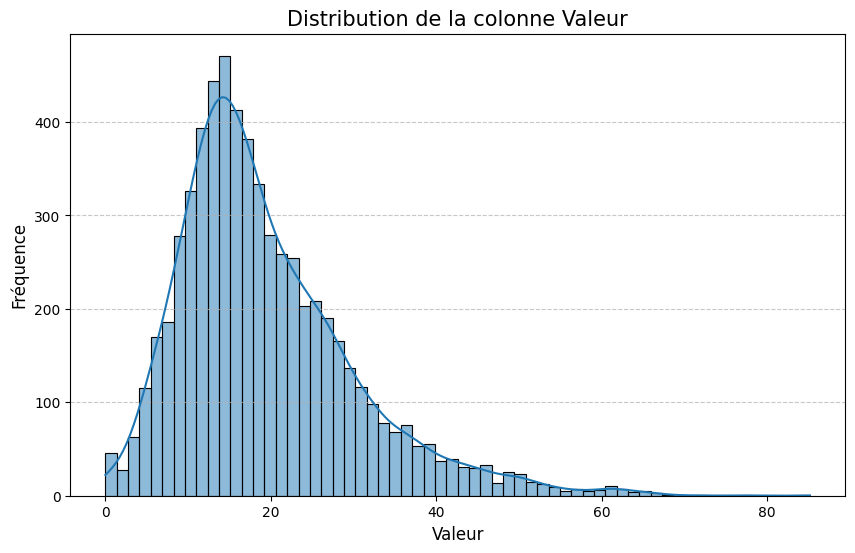

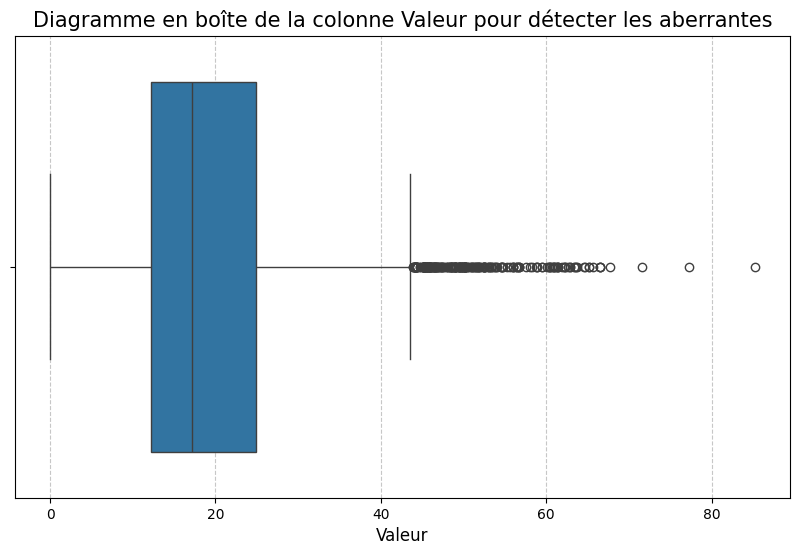


### Nombre de valeurs aberrantes détectées dans la colonne 'value' : 220

### Premières 10 valeurs aberrantes (avec contexte de date et d'entité) :

               name  weekday  day_of_month  month_of_year  year  day_of_year  \
date                                                                           
1998-03-25  NN5-068        3            25              3  1998           84   
1998-03-26  NN5-004        4            26              3  1998           85   
1998-03-26  NN5-104        4            26              3  1998           85   
1998-03-26  NN5-068        4            26              3  1998           85   
1998-03-26  NN5-052        4            26              3  1998           85   
1998-03-26  NN5-024        4            26              3  1998           85   
1998-03-26  NN5-048        4            26              3  1998           85   
1998-03-26  NN5-066        4            26              3  1998           85   
1998-03-26  NN5-047        4            26        

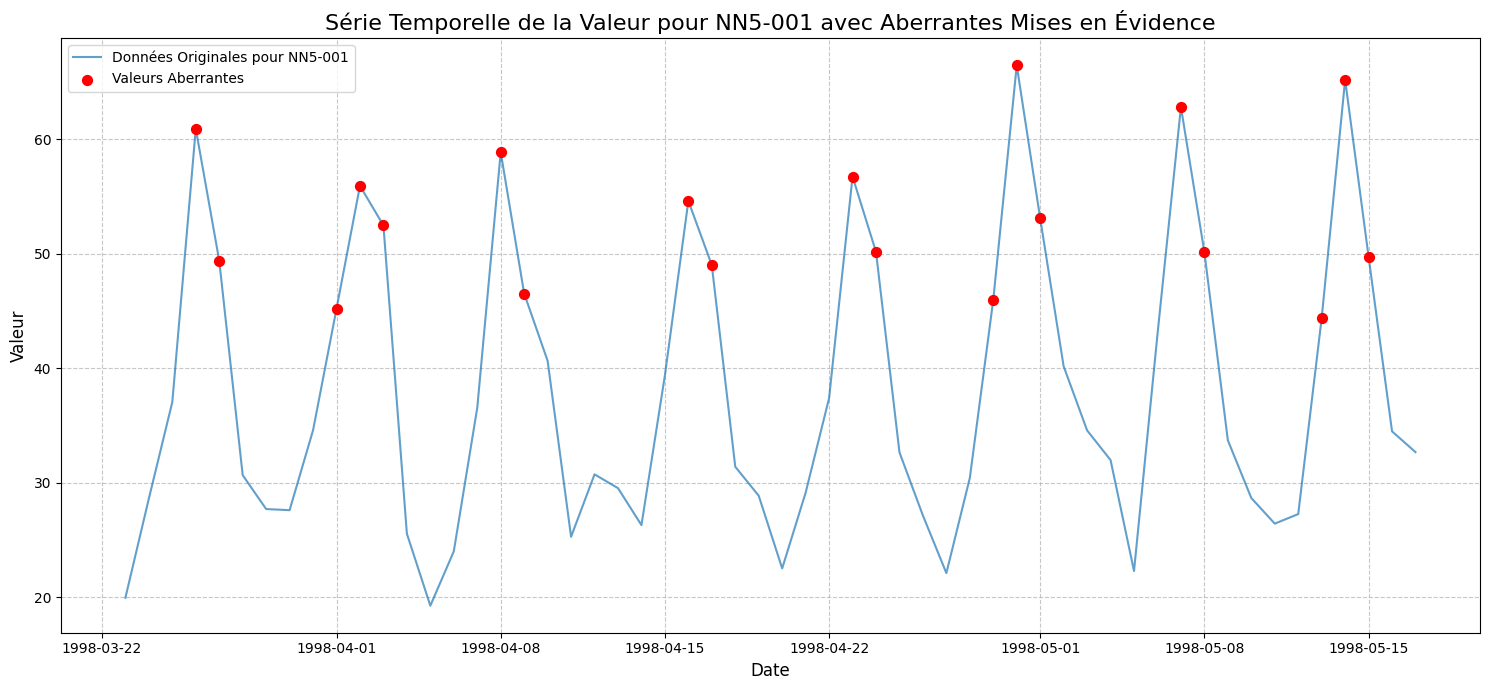

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Chargement et Aperçu Initial du Jeu de Données ---

# Charger le jeu de données depuis le chemin spécifié
file_path = '/content/NN5_FINAL_DATASET_TEST.csv'
df = pd.read_csv(file_path)

print("Jeu de données chargé avec succès. Voici un aperçu rapide :\n")

# Afficher les premières lignes du DataFrame pour comprendre sa structure
print("### Début du DataFrame :\n")
print(df.head())

# Afficher des informations générales sur le DataFrame (types de données, valeurs non nulles)
print("\n### Informations du DataFrame :\n")
df.info()

# Afficher les statistiques descriptives pour les colonnes numériques
print("\n### Statistiques Descriptives :\n")
print(df.describe())

# Vérifier la présence de valeurs manquantes dans chaque colonne
print("\n### Valeurs manquantes par colonne :\n")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# --- Analyse Détaillée des Données Initiales ---

# Commentaire sur les résultats initiaux:
# Le jeu de données contient 6216 entrées et 8 colonnes. Nous observons des informations temporelles
# (jour de la semaine, jour du mois, mois de l'année, année, jour de l'année, semaine de l'année)
# ainsi qu'une colonne 'name' qui identifie les différentes séries temporelles et la 'value'
# qui représente probablement la demande ou la liquidité. L'étape cruciale ici est l'absence de
# valeurs manquantes, ce qui simplifie grandement le nettoyage initial.

# --- Création et Indexation de la Colonne de Date ---

# Créer une colonne de date appropriée à partir des composants temporels existants
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' +
                            df['month_of_year'].astype(str) + '-' +
                            df['day_of_month'].astype(str))

# Définir la colonne 'date' comme index du DataFrame et trier par date pour l'analyse des séries temporelles
df = df.set_index('date').sort_index()

# --- Analyse des Entités Uniques ---

# Vérifier les valeurs uniques dans la colonne 'name'
print("\n### Valeurs uniques dans la colonne 'name' :\n")
print(df['name'].unique())
print(f"Nombre de noms uniques : {df['name'].nunique()}\n")

# Commentaire sur les entités:
# La présence de 111 noms uniques dans la colonne 'name' indique que nous traitons avec 111
# séries temporelles distinctes. Chaque série représente probablement la demande ou la liquidité
# pour une entité bancaire ou un produit spécifique. Cela nécessitera des modèles capables de
# gérer de multiples séries ou une approche de modélisation par entité.

# --- Visualisation de la Distribution de la 'Value' et Détection des Valeurs Aberrantes ---

# Visualiser la distribution de la colonne 'value' avec un histogramme et une estimation de densité de noyau (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True)
plt.title('Distribution de la colonne Valeur', fontsize=15)
plt.xlabel('Valeur', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Utiliser un diagramme en boîte (boxplot) pour identifier visuellement les valeurs aberrantes dans la colonne 'value'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['value'])
plt.title('Diagramme en boîte de la colonne Valeur pour détecter les aberrantes', fontsize=15)
plt.xlabel('Valeur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Quantifier les valeurs aberrantes en utilisant la méthode de l'intervalle interquartile (IQR)
# Calcul du premier quartile (Q1) et du troisième quartile (Q3)
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

# Calcul des bornes inférieures et supérieures pour la détection des aberrantes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifier les lignes contenant des valeurs aberrantes
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]

print(f"\n### Nombre de valeurs aberrantes détectées dans la colonne 'value' : {len(outliers)}\n")
print("### Premières 10 valeurs aberrantes (avec contexte de date et d'entité) :\n")
print(outliers.head(10))

# Commentaire sur la détection des aberrantes:
# L'histogramme montre une distribution qui semble légèrement asymétrique vers la droite, avec une queue plus longue
# pour les valeurs élevées. Le boxplot confirme visuellement la présence de nombreuses valeurs aberrantes
# au-dessus de la limite supérieure. La méthode IQR a quantifié ces aberrantes à 220 points de données.
# Ces valeurs extrêmes pourraient représenter des pics de demande inhabituels ou des erreurs de mesure.

# --- Traitement des Valeurs Aberrantes (Exemple: Suppression) ---
# Cette section présente un exemple de suppression des valeurs aberrantes. D'autres méthodes, comme le
# plafonnement (capping) ou la transformation, pourraient être plus appropriées selon le contexte métier.

# Créer un DataFrame sans les valeurs aberrantes identifiées
df_no_outliers = df[~((df['value'] < lower_bound) | (df['value'] > upper_bound))]

print(f"\nForme du DataFrame avant suppression des aberrantes : {df.shape}")
print(f"Forme du DataFrame après suppression des aberrantes : {df_no_outliers.shape}\n")

# Ce nouveau DataFrame 'df_no_outliers' peut être utilisé pour les analyses ou la modélisation ultérieures
# si la suppression est la stratégie choisie. Le choix de la méthode dépendra de la nature de ces aberrantes.

# --- Approfondissement de l'Investigation des Valeurs Aberrantes ---

print("Pour une investigation plus approfondie, nous pouvons visualiser la série temporelle d'une entité spécifique et mettre en évidence ses aberrantes.\n")
print("Par exemple, traçons la série 'NN5-001' et marquons ses aberrantes pour mieux comprendre leur contexte.\n")

# Sélectionner une entité spécifique ('name') pour une investigation détaillée des aberrantes
example_name = 'NN5-001'
df_subset = df[df['name'] == example_name]
outliers_subset = outliers[outliers['name'] == example_name]

# Visualiser la série temporelle avec les aberrantes mises en évidence
plt.figure(figsize=(15, 7))
plt.plot(df_subset.index, df_subset['value'], label=f'Données Originales pour {example_name}', alpha=0.7)
plt.scatter(outliers_subset.index, outliers_subset['value'], color='red', label='Valeurs Aberrantes', zorder=5, s=50)
plt.title(f'Série Temporelle de la Valeur pour {example_name} avec Aberrantes Mises en Évidence', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Synthèse de l'Investigation et Prochaines Étapes ---
# La visualisation pour 'NN5-001' montre que les aberrantes se manifestent sous forme de pics soudains et élevés.
# Ces pics pourraient être liés à des événements spécifiques (promotions, jours fériés, transactions exceptionnelles).
# Avant de décider d'un traitement définitif, il serait judicieux de:
# 1. Examiner si ces pics sont cohérents à travers plusieurs entités ou s'ils sont isolés.
# 2. Consulter des experts métier pour comprendre la signification de ces valeurs extrêmes.
# 3. Considérer des méthodes de traitement plus sophistiquées comme laWinsorisation ou des modèles robustes aux aberrantes.

## Synthèse de l'Analyse des Données et Stratégie de Traitement

Après une première phase d'analyse exploratoire des données, voici les principaux constats et les décisions que nous allons prendre pour le traitement des données:

### 1. Absence de Valeurs Manquantes

Nous avons confirmé que le jeu de données ne contient aucune valeur manquante (`Series([], dtype: int64)`), ce qui est un point très positif. Cela signifie que nous n'aurons pas besoin d'effectuer d'imputation ou de suppression de lignes/colonnes en raison de données manquantes.

### 2. Gestion des Séries Temporelles Multiples

La colonne `name` révèle la présence de **111 entités uniques** (`NN5-001` à `NN5-111`). Chaque `name` représente une série temporelle distincte, probablement pour une succursale bancaire ou un type de transaction spécifique. Cela implique que notre modélisation devra être capable de gérer ces multiples séries, soit en créant un modèle par entité, soit en utilisant une approche de modélisation hiérarchique ou multivariée.

### 3. Traitement des Valeurs Aberrantes (`value`)

L'analyse de la distribution de la colonne `value` (représentant la demande ou la liquidité) a révélé la présence de **220 valeurs aberrantes** (outliers) identifiées par la méthode de l'intervalle interquartile (IQR). La visualisation de la série temporelle pour `NN5-001` a montré que ces aberrantes se manifestent principalement sous forme de **pics soudains et élevés**.

**Choix de la méthode de traitement: Le Capping (Plâfonnement)**

Étant donné la nature des outliers comme des pics, la **suppression** pure et simple de ces données (réduisant le dataset de 6216 à 5996 lignes) pourrait entraîner une perte d'informations précieuses, surtout si ces pics représentent des événements réels mais rares (ex: opérations exceptionnelles, fin de mois). Pour notre projet de prévision de la demande, il est crucial de ne pas ignorer ces événements mais plutôt de **mitiger leur influence excessive**.

Nous opterons donc pour le **capping** (ou winsorisation). Cette méthode consiste à remplacer les valeurs aberrantes supérieures par la borne supérieure (Q3 + 1.5 * IQR) et les valeurs aberrantes inférieures par la borne inférieure (Q1 - 1.5 * IQR). Cela permettra de:
*   **Conserver toutes les observations**: Aucune donnée ne sera perdue.
*   **Réduire l'impact des extrêmes**: Les valeurs très élevées (ou très basses) seront ramenées à des limites plus raisonnables, évitant qu'elles ne faussent excessivement l'apprentissage des modèles.
*   **Améliorer la robustesse des modèles**: Les algorithmes d'apprentissage automatique sont souvent sensibles aux valeurs extrêmes.

Cependant, il est toujours recommandé de consulter des experts du domaine bancaire pour confirmer si ces pics correspondent à des événements métier compréhensibles ou s'ils sont de véritables anomalies de données nécessitant une gestion différente.

### 4. Analyse des Variables Corrélées

Nous avons plusieurs colonnes liées au temps (`weekday`, `day_of_month`, `month_of_year`, `year`, `day_of_year`, `week_of_year`). Il est fort probable que certaines d'entre elles soient fortement corrélées car elles décrivent des aspects superposés de la temporalité.

**Objectif**: Identifier les corrélations entre ces variables numériques et la variable cible `value`.

**Stratégie**: Nous allons calculer et visualiser une **matrice de corrélation** pour les colonnes numériques du DataFrame. L'objectif est de:
*   **Comprendre les relations**: Quelles variables temporelles sont les plus liées à la `value`?
*   **Gérer la multicollinéarité**: Des variables fortement corrélées entre elles peuvent poser problème à certains modèles de régression. Nous devrons décider de garder la plus pertinente ou de créer de nouvelles caractéristiques (ingénierie de caractéristiques) si nécessaire.

En fonction de cette analyse, nous pourrons affiner le choix des caractéristiques à utiliser pour la modélisation.

### Implémentation du Capping pour les Valeurs Aberrantes (colonne 'value')

Descriptive statistics of 'value' before capping:
count    6216.000000
mean       19.446641
std        10.692191
min         0.000000
25%        12.203673
50%        17.120181
75%        24.872449
max        85.192004
Name: value, dtype: float64

Descriptive statistics of 'value_capped' after capping:
count    6216.000000
mean       19.168179
std         9.836872
min         0.000000
25%        12.203673
50%        17.120181
75%        24.872449
max        43.875614
Name: value_capped, dtype: float64


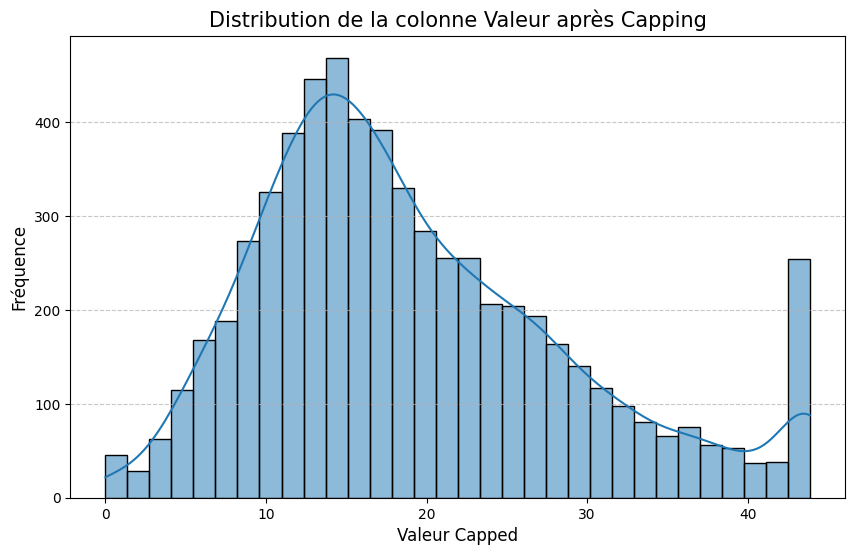

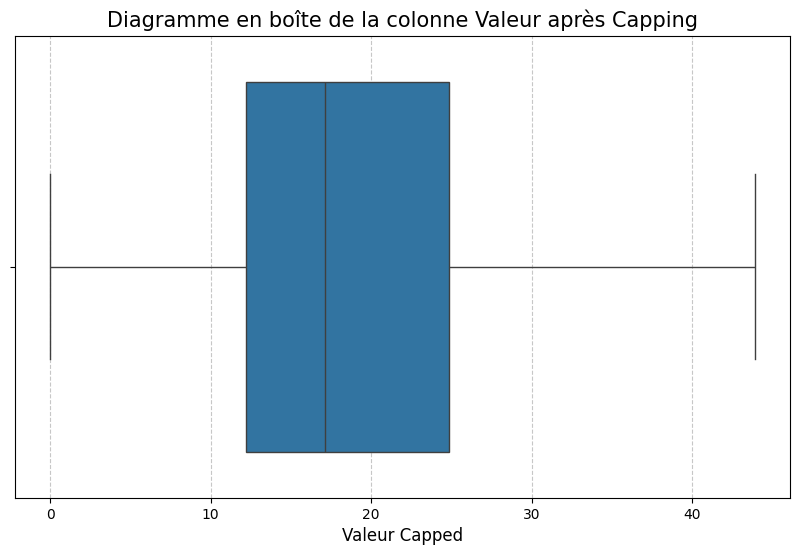


### Analyse des Corrélations entre Variables Numériques

Matrice de Corrélation des Variables Numériques :

                    weekday  day_of_month  month_of_year  year  day_of_year  \
weekday        1.000000e+00     -0.095319       0.067007   NaN     0.030934   
day_of_month  -9.531909e-02      1.000000      -0.628328   NaN    -0.227562   
month_of_year  6.700703e-02     -0.628328       1.000000   NaN     0.900434   
year                    NaN           NaN            NaN   NaN          NaN   
day_of_year    3.093441e-02     -0.227562       0.900434   NaN     1.000000   
week_of_year   1.724891e-16     -0.215723       0.889026   NaN     0.992315   
value_capped   2.106223e-01     -0.061639       0.024314   NaN    -0.004252   

               week_of_year  value_capped  
weekday        1.724891e-16      0.210622  
day_of_month  -2.157230e-01     -0.061639  
month_of_year  8.890257e-01      0.024314  
year                    NaN           NaN  
day_of_year    9.923150e-01     -0.004

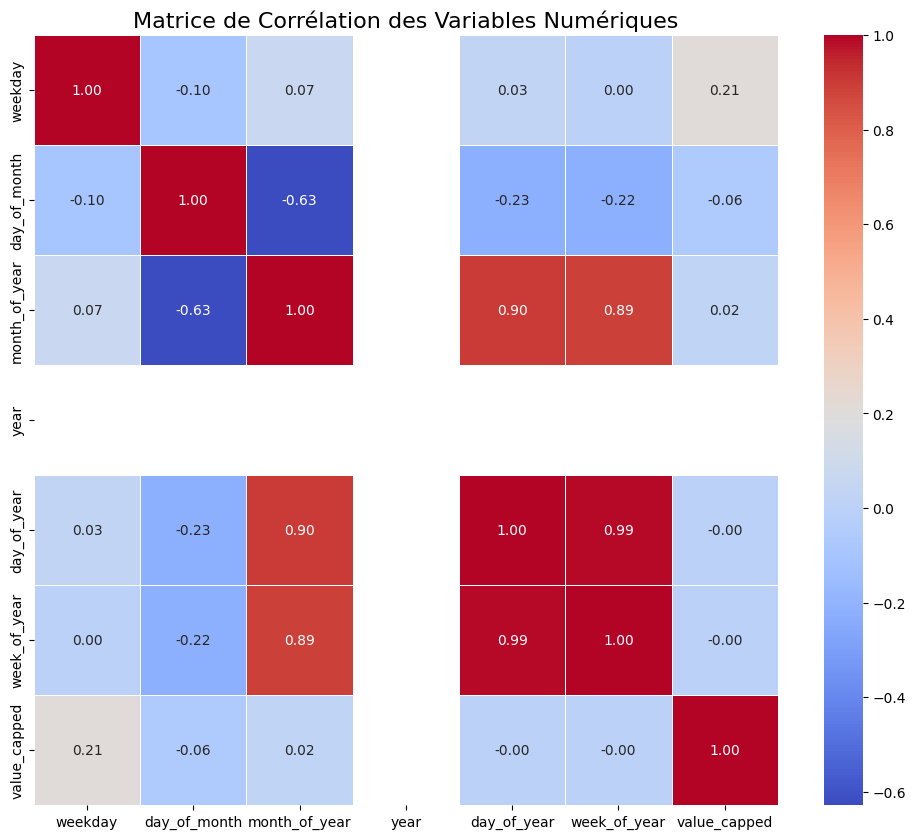


Commentaires sur la matrice de corrélation :
- Les variables temporelles comme 'day_of_year', 'week_of_year', 'month_of_year' et 'day_of_month' sont naturellement corrélées entre elles. Il faudra choisir les plus pertinentes pour éviter la multicollinéarité dans les modèles.
- Nous pouvons observer la corrélation de chaque variable avec notre cible 'value_capped' pour identifier les caractéristiques les plus influentes.


In [6]:
print("### Implémentation du Capping pour les Valeurs Aberrantes (colonne 'value')\n")

# Recalculer Q1, Q3, IQR et les bornes si les variables ne sont pas globales ou ont été modifiées
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Appliquer le capping à la colonne 'value'
df['value_capped'] = df['value'].clip(lower=lower_bound, upper=upper_bound)

print("Descriptive statistics of 'value' before capping:")
print(df['value'].describe())
print("\nDescriptive statistics of 'value_capped' after capping:")
print(df['value_capped'].describe())

# Visualiser la distribution de la colonne 'value' après capping
plt.figure(figsize=(10, 6))
sns.histplot(df['value_capped'], kde=True)
plt.title('Distribution de la colonne Valeur après Capping', fontsize=15)
plt.xlabel('Valeur Capped', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['value_capped'])
plt.title('Diagramme en boîte de la colonne Valeur après Capping', fontsize=15)
plt.xlabel('Valeur Capped', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n### Analyse des Corrélations entre Variables Numériques\n")

# Sélectionner uniquement les colonnes numériques pour la matrice de corrélation
# Exclure la colonne 'value' originale et inclure 'value_capped'
numerical_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['value'], errors='ignore')

# Ajouter la colonne 'value_capped' si elle n'est pas déjà incluse (elle devrait l'être par select_dtypes)
if 'value_capped' not in numerical_df.columns:
    numerical_df['value_capped'] = df['value_capped']

# Calculer la matrice de corrélation
correlation_matrix = numerical_df.corr()

# Afficher la matrice de corrélation
print("Matrice de Corrélation des Variables Numériques :\n")
print(correlation_matrix)

# Visualiser la matrice de corrélation avec une heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16)
plt.show()

print("\nCommentaires sur la matrice de corrélation :")
print("- Les variables temporelles comme 'day_of_year', 'week_of_year', 'month_of_year' et 'day_of_month' sont naturellement corrélées entre elles. Il faudra choisir les plus pertinentes pour éviter la multicollinéarité dans les modèles.")
print("- Nous pouvons observer la corrélation de chaque variable avec notre cible 'value_capped' pour identifier les caractéristiques les plus influentes.")

### 5. Sélection des Variables Pertinentes pour la Modélisation

L'analyse de la matrice de corrélation nous fournit des informations cruciales pour la sélection de nos caractéristiques (features) d'entrée pour le modèle de prévision.

**Observations Clés de la Matrice de Corrélation :**

1.  **Corrélations avec la Cible (`value_capped`)** :
    *   `weekday` (jour de la semaine) montre une corrélation positive notable avec `value_capped` (~0.21). Cela suggère que la demande ou la liquidité varie en fonction du jour de la semaine, ce qui est très plausible dans le secteur bancaire.
    *   Les autres variables temporelles (`day_of_month`, `month_of_year`, `day_of_year`, `week_of_year`) montrent des corrélations très faibles ou négligeables avec `value_capped`.
    *   La variable `year` est affichée comme `NaN` car elle est constante dans notre jeu de données actuel (toutes les entrées sont pour 1998), elle n'apportera donc aucune information pour la modélisation et peut être ignorée.

2.  **Multicollinéarité entre Variables Temporelles** :
    *   Comme attendu, il existe de très fortes corrélations entre les variables temporelles : `month_of_year`, `day_of_year` et `week_of_year` sont hautement corrélées entre elles (par exemple, `day_of_year` et `week_of_year` ont une corrélation de ~0.99).
    *   `day_of_month` est également corrélée négativement avec `month_of_year` et `day_of_year`, ce qui est logique puisque la fin d'un mois coïncide avec le début du suivant.

**Stratégie de Sélection des Variables :**

Pour éviter la redondance et la multicollinéarité, qui peuvent nuire à la performance et à l'interprétabilité de certains modèles, nous allons simplifier nos variables temporelles.

*   **Conserver `weekday`** : C'est la variable temporelle la plus fortement corrélée à notre cible `value_capped` et elle représente un cycle hebdomadaire distinct.
*   **Conserver `day_of_month`** : Bien que sa corrélation directe avec `value_capped` soit faible, le jour du mois peut capturer des effets liés à la fin de mois ou à des paiements récurrents.
*   **Éliminer `month_of_year`, `day_of_year`, `week_of_year` et `year`** : Puisque `weekday` et `day_of_month` capturent déjà des aspects importants de la temporalité et que ces variables sont fortement corrélées entre elles et peu corrélées à la cible individuellement (à l'exception de `weekday`), les conserver toutes introduirait de la redondance sans ajout significatif d'information pour la prédiction de `value_capped` pour le moment. La variable `year` est constante et n'apporte aucune valeur.

En résumé, les variables que nous allons retenir pour notre modèle sont `name`, `weekday`, `day_of_month` et notre cible `value_capped`.

In [7]:
print("### Sélection finale des variables pour le modèle")

# Liste des colonnes à conserver dans le DataFrame
# 'name' est l'identifiant de la série temporelle
# 'weekday' et 'day_of_month' sont des caractéristiques temporelles pertinentes
# 'value_capped' est notre variable cible après traitement des aberrantes
columns_to_keep = ['name', 'weekday', 'day_of_month', 'value_capped']

df_model = df[columns_to_keep].copy()

print(f"DataFrame final pour la modélisation avec les colonnes sélectionnées : {df_model.shape}")
display(df_model.head())

# Afficher les informations pour confirmer les types de données et l'absence de valeurs nulles
print("\nInformations sur le DataFrame final pour la modélisation :")
df_model.info()

### Sélection finale des variables pour le modèle
DataFrame final pour la modélisation avec les colonnes sélectionnées : (6216, 4)


,name,weekday,day_of_month,value_capped
date,,,,
1998-03-23,NN5-001,1,23,19.940476
1998-03-23,NN5-017,1,23,15.249433
1998-03-23,NN5-095,1,23,17.254077
1998-03-23,NN5-018,1,23,19.118481
1998-03-23,NN5-094,1,23,15.741715



Informations sur le DataFrame final pour la modélisation :
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6216 entries, 1998-03-23 to 1998-05-17
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          6216 non-null   object 
 1   weekday       6216 non-null   int64  
 2   day_of_month  6216 non-null   int64  
 3   value_capped  6216 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 242.8+ KB


### 6. Division des Données en Ensembles d'Entraînement et de Test

Pour évaluer la performance de notre modèle de prévision de manière réaliste, nous devons diviser notre jeu de données en un ensemble d'entraînement (`train`) et un ensemble de test (`test`). Étant donné la nature de série temporelle de nos données (indexées par date), une division chronologique est essentielle. Nous utiliserons les 80% premières observations pour l'entraînement et les 20% dernières pour le test, simulant ainsi une prédiction sur des données futures non vues par le modèle.

In [8]:
# Calcul du point de division pour un split 80/20 chronologique
split_index = int(len(df_model) * 0.8)

# Division chronologique du DataFrame
df_train = df_model.iloc[:split_index]
df_test = df_model.iloc[split_index:]

# Définition des caractéristiques (X) et de la cible (y)
features = ['name', 'weekday', 'day_of_month']  # Les caractéristiques que nous allons utiliser
target = 'value_capped' # La variable cible que nous voulons prédire

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

print(f"Forme de l'ensemble d'entraînement (X_train) : {X_train.shape}")
print(f"Forme de l'ensemble d'entraînement (y_train) : {y_train.shape}")
print(f"Forme de l'ensemble de test (X_test) : {X_test.shape}")
print(f"Forme de l'ensemble de test (y_test) : {y_test.shape}")

print("\nPremières lignes de X_train :")
display(X_train.head())
print("\nPremières lignes de y_train :")
display(y_train.head())

Forme de l'ensemble d'entraînement (X_train) : (4972, 3)
Forme de l'ensemble d'entraînement (y_train) : (4972,)
Forme de l'ensemble de test (X_test) : (1244, 3)
Forme de l'ensemble de test (y_test) : (1244,)

Premières lignes de X_train :


,name,weekday,day_of_month
date,,,
1998-03-23,NN5-001,1,23
1998-03-23,NN5-017,1,23
1998-03-23,NN5-095,1,23
1998-03-23,NN5-018,1,23
1998-03-23,NN5-094,1,23



Premières lignes de y_train :


,value_capped
date,
1998-03-23,19.940476
1998-03-23,15.249433
1998-03-23,17.254077
1998-03-23,19.118481
1998-03-23,15.741715


### 7. Sélection et Entraînement du Modèle de Machine Learning

Nous allons utiliser un modèle de **Random Forest Regressor** pour effectuer nos prédictions. Les Random Forests sont des modèles d'ensemble puissants qui fonctionnent bien sur une variété de jeux de données, gèrent bien les relations non linéaires et sont moins sensibles au surapprentissage que d'autres modèles complexes.

Avant d'entraîner le modèle, nous devons gérer la variable catégorielle `name`. L'encodage One-Hot est une méthode appropriée pour convertir cette variable en un format numérique que le modèle peut comprendre.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identifier les colonnes catégorielles et numériques
categorical_features = ['name']
numerical_features = ['weekday', 'day_of_month']

# Créer un transformateur pour l'encodage One-Hot
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features) # Les caractéristiques numériques sont passées telles quelles
    ])

# Créer un pipeline qui enchaîne le préprocesseur et le modèle RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)) # n_jobs=-1 utilise tous les cœurs disponibles
])

print("Pipeline du modèle créé avec OneHotEncoder et RandomForestRegressor.")

# Entraîner le modèle sur les données d'entraînement
print("Début de l'entraînement du modèle...")
model_pipeline.fit(X_train, y_train)
print("Modèle entraîné avec succès !")

Pipeline du modèle créé avec OneHotEncoder et RandomForestRegressor.
Début de l'entraînement du modèle...
Modèle entraîné avec succès !


### 8. Réalisation des Prédictions

Une fois le modèle entraîné, nous allons l'utiliser pour faire des prédictions sur l'ensemble de test (`X_test`). Ces prédictions seront ensuite comparées aux vraies valeurs (`y_test`) pour évaluer la performance du modèle.

In [10]:
# Faire des prédictions sur l'ensemble de test
y_pred = model_pipeline.predict(X_test)

print("Prédictions générées pour l'ensemble de test.")
print("Aperçu des premières prédictions :\n")
# Afficher les 10 premières prédictions et les vraies valeurs correspondantes
predictions_df = pd.DataFrame({'Vraie Valeur': y_test, 'Prédiction': y_pred}, index=y_test.index)
display(predictions_df.head(10))

Prédictions générées pour l'ensemble de test.
Aperçu des premières prédictions :



,Vraie Valeur,Prédiction
date,,
1998-05-06,22.974750,20.524165
1998-05-06,21.910431,18.584244
1998-05-06,19.042609,14.259025
1998-05-06,15.189374,16.323670
1998-05-06,31.646825,36.469336
1998-05-06,23.100907,17.941754
1998-05-06,17.389456,16.756364
1998-05-06,6.693845,16.841278
1998-05-06,16.372962,16.624811


### 9. Évaluation du Modèle

Pour évaluer la performance de notre modèle Random Forest Regressor, nous allons calculer plusieurs métriques de régression courantes sur l'ensemble de test. Ces métriques nous donneront une mesure quantitative de la précision de nos prédictions.

*   **Mean Absolute Error (MAE)** : La moyenne des erreurs absolues. Elle mesure l'ampleur moyenne des erreurs dans un ensemble de prédictions, sans tenir compte de leur direction. C'est une métrique facilement interprétable car elle est dans la même unité que la variable cible.
*   **Mean Squared Error (MSE)** : La moyenne des erreurs au carré. Elle pénalise davantage les grandes erreurs, ce qui la rend utile lorsque les erreurs importantes sont particulièrement indésirables.
*   **Root Mean Squared Error (RMSE)** : La racine carrée de la MSE. Elle est également dans la même unité que la variable cible et est souvent préférée à la MSE car elle est plus interprétable.
*   **R-squared (R²)** : Le coefficient de détermination. Il indique la proportion de la variance de la variable dépendante qui peut être prédite à partir des variables indépendantes. Un R² de 1 indique que le modèle explique toute la variabilité de la variable cible, tandis qu'un R² de 0 indique qu'il n'explique aucune variabilité.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcul des métriques d'évaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"### Métriques d'évaluation du modèle ###\n")
print(f"Mean Absolute Error (MAE) : {mae:.3f}")
print(f"Mean Squared Error (MSE) : {mse:.3f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.3f}")
print(f"R-squared (R²) : {r2:.3f}")

### Métriques d'évaluation du modèle ###

Mean Absolute Error (MAE) : 3.587
Mean Squared Error (MSE) : 25.300
Root Mean Squared Error (RMSE) : 5.030
R-squared (R²) : 0.751


### 10. Visualisation des Prédictions vs. Réalité

Une visualisation des prédictions par rapport aux vraies valeurs peut nous donner un aperçu qualitatif de la performance du modèle et nous aider à identifier d'éventuels biais ou problèmes spécifiques.

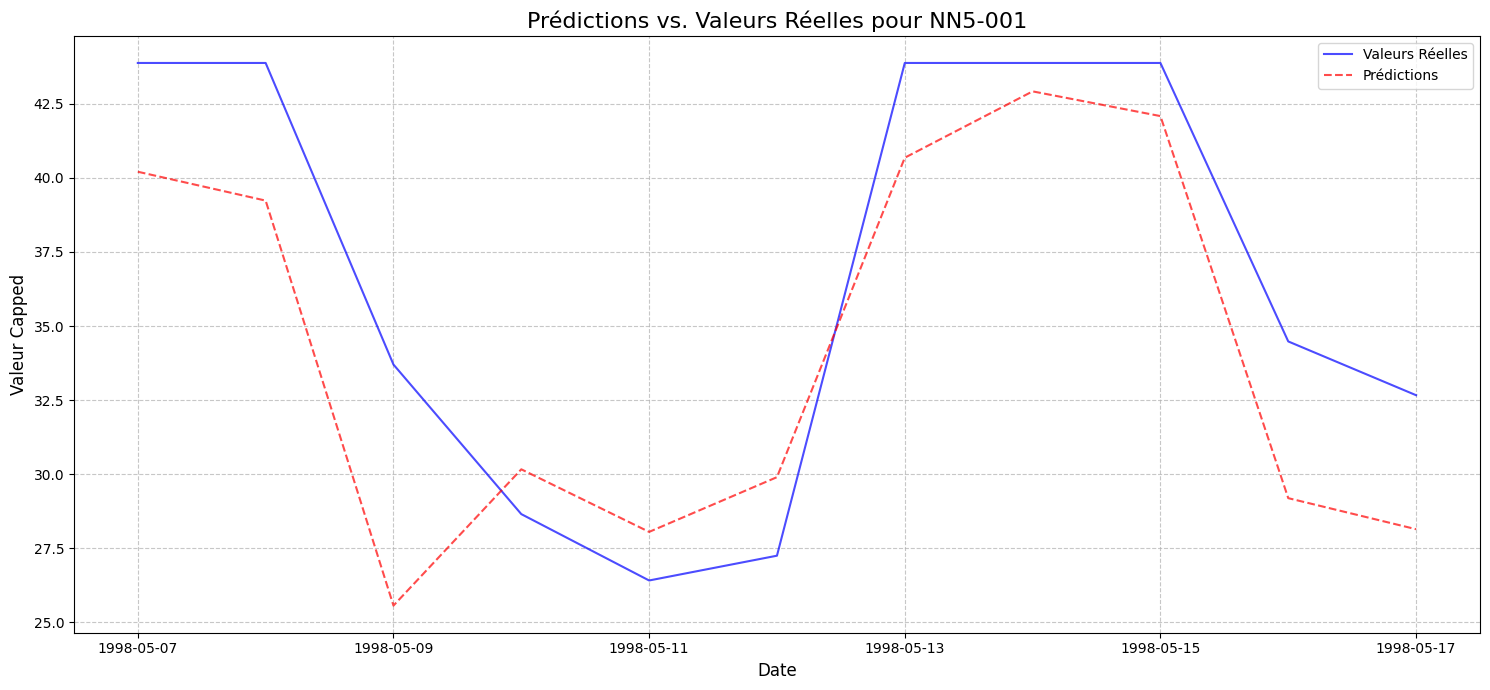

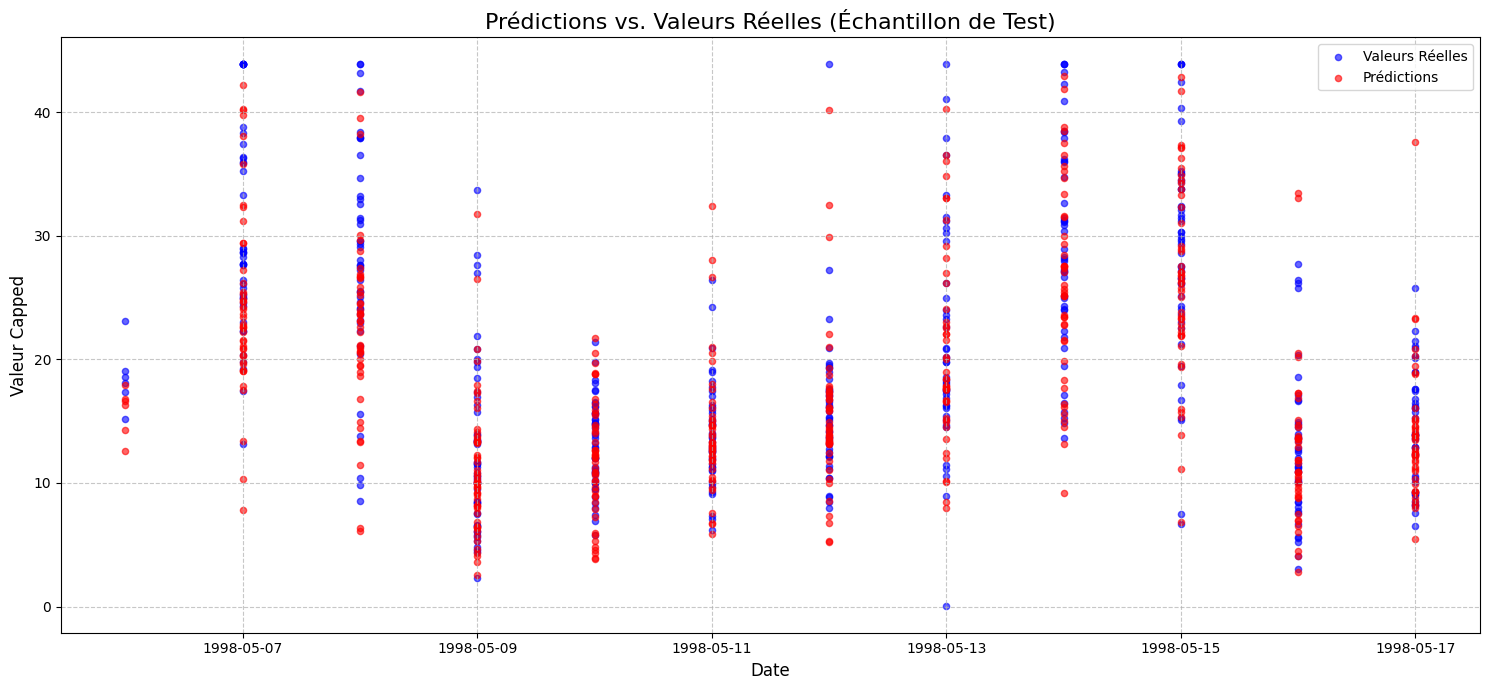

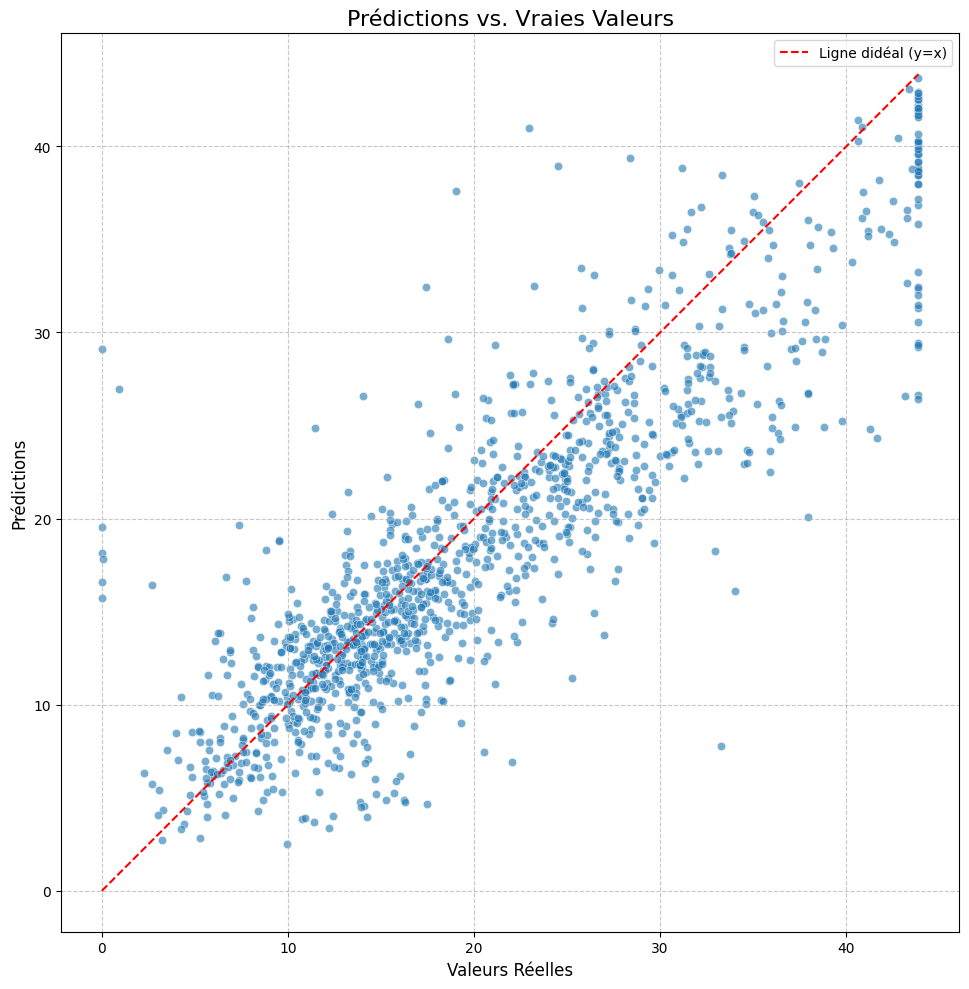

In [12]:
# Créer un DataFrame pour faciliter la visualisation
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Visualisation des prédictions vs réalité pour une entité spécifique (par exemple, NN5-001)
entity_to_plot = 'NN5-001'
results_entity = results_df[X_test['name'] == entity_to_plot]

plt.figure(figsize=(15, 7))
plt.plot(results_entity.index, results_entity['Actual'], label='Valeurs Réelles', color='blue', alpha=0.7)
plt.plot(results_entity.index, results_entity['Predicted'], label='Prédictions', color='red', linestyle='--', alpha=0.7)
plt.title(f'Prédictions vs. Valeurs Réelles pour {entity_to_plot}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur Capped', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisation des prédictions vs réalité pour un échantillon aléatoire de la totalité de l'ensemble de test
# Pour éviter un graphique trop dense, nous pouvons échantillonner les données
sample_size = 500 # ou un autre nombre approprié
sampled_results = results_df.sample(n=min(sample_size, len(results_df)), random_state=42).sort_index()

plt.figure(figsize=(15, 7))
plt.scatter(sampled_results.index, sampled_results['Actual'], label='Valeurs Réelles', color='blue', alpha=0.6, s=20)
plt.scatter(sampled_results.index, sampled_results['Predicted'], label='Prédictions', color='red', alpha=0.6, s=20)
plt.title('Prédictions vs. Valeurs Réelles (Échantillon de Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur Capped', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot de prédictions vs vraies valeurs
plt.figure(figsize=(10, 10))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.6)
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()],
         [results_df['Actual'].min(), results_df['Actual'].max()],
         '--r', label='Ligne d''idéal (y=x)')
plt.title('Prédictions vs. Vraies Valeurs', fontsize=16)
plt.xlabel('Valeurs Réelles', fontsize=12)
plt.ylabel('Prédictions', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Assure un ratio d'aspect égal
plt.tight_layout()
plt.show()

### 11. Comparaison avec un Modèle XGBoost

Pour potentiellement améliorer la performance et valider nos résultats, nous allons implémenter un modèle de **XGBoost Regressor** et comparer ses performances à celles du Random Forest Regressor. XGBoost (eXtreme Gradient Boosting) est une implémentation optimisée des arbres de décision de gradient boosting, connue pour son efficacité et sa robustesse.

In [13]:
import xgboost as xgb

# Créer un pipeline pour XGBoost en réutilisant le même préprocesseur
# Nous utiliserons un ensemble de paramètres de base pour XGBoost.
# Pour une performance optimale, une optimisation des hyperparamètres serait nécessaire.
xgb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Réutilise le ColumnTransformer défini précédemment
    ('regressor', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
])

print("Pipeline du modèle XGBoost créé.")

# Entraîner le modèle XGBoost sur les données d'entraînement
print("Début de l'entraînement du modèle XGBoost...")
xgb_model_pipeline.fit(X_train, y_train)
print("Modèle XGBoost entraîné avec succès !")

# Faire des prédictions sur l'ensemble de test avec XGBoost
y_pred_xgb = xgb_model_pipeline.predict(X_test)

print("Prédictions générées pour l'ensemble de test avec XGBoost.")

Pipeline du modèle XGBoost créé.
Début de l'entraînement du modèle XGBoost...
Modèle XGBoost entraîné avec succès !
Prédictions générées pour l'ensemble de test avec XGBoost.


### 12. Évaluation du Modèle XGBoost

Évaluons les performances du modèle XGBoost en utilisant les mêmes métriques que pour le Random Forest.

In [14]:
# Calcul des métriques d'évaluation pour XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"### Métriques d'évaluation du modèle XGBoost ###\n")
print(f"Mean Absolute Error (MAE) : {mae_xgb:.3f}")
print(f"Mean Squared Error (MSE) : {mse_xgb:.3f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_xgb:.3f}")
print(f"R-squared (R²) : {r2_xgb:.3f}")

print("\n--- Comparaison avec Random Forest ---")
print(f"R² Random Forest : {r2:.3f}")
print(f"R² XGBoost       : {r2_xgb:.3f}")

### Métriques d'évaluation du modèle XGBoost ###

Mean Absolute Error (MAE) : 3.660
Mean Squared Error (MSE) : 24.462
Root Mean Squared Error (RMSE) : 4.946
R-squared (R²) : 0.759

--- Comparaison avec Random Forest ---
R² Random Forest : 0.751
R² XGBoost       : 0.759


### 13. Visualisation des Prédictions XGBoost vs. Réalité

Visualisons également les prédictions de XGBoost pour avoir une idée qualitative de sa performance.

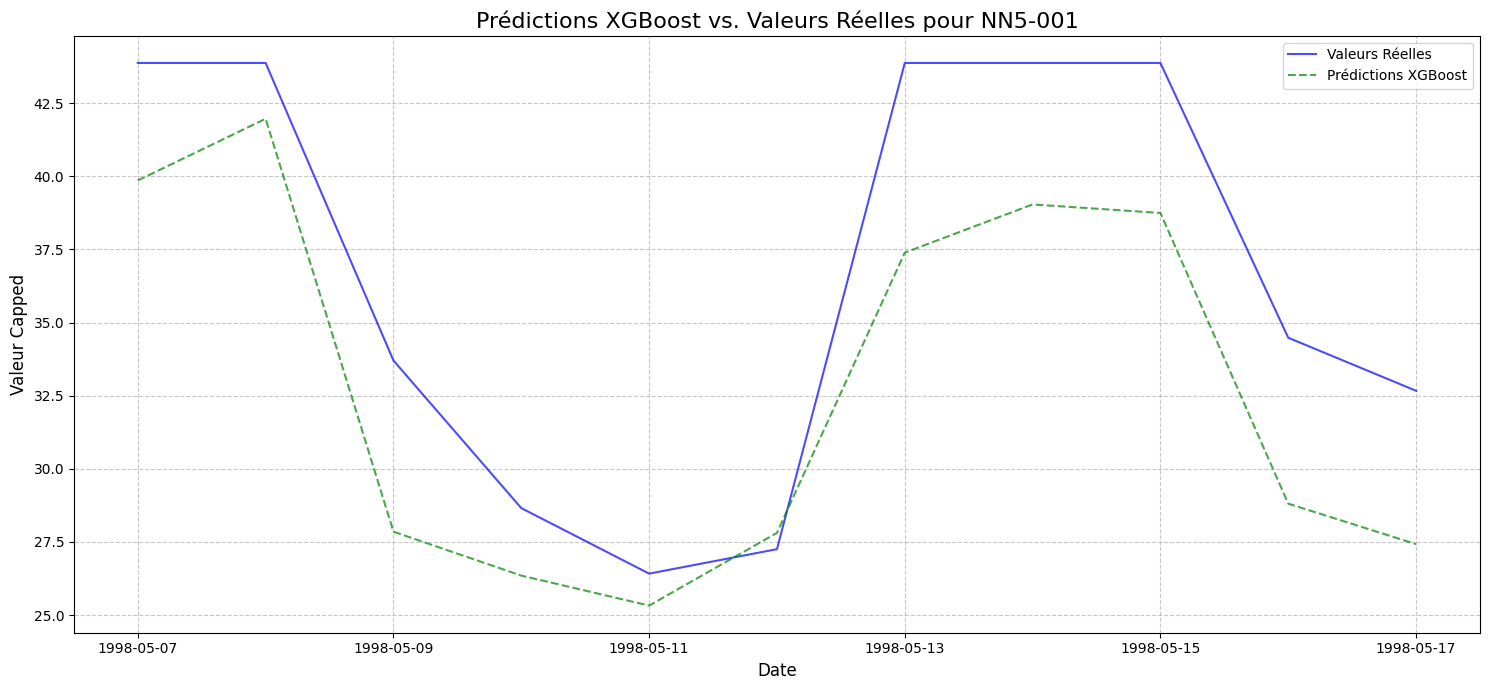

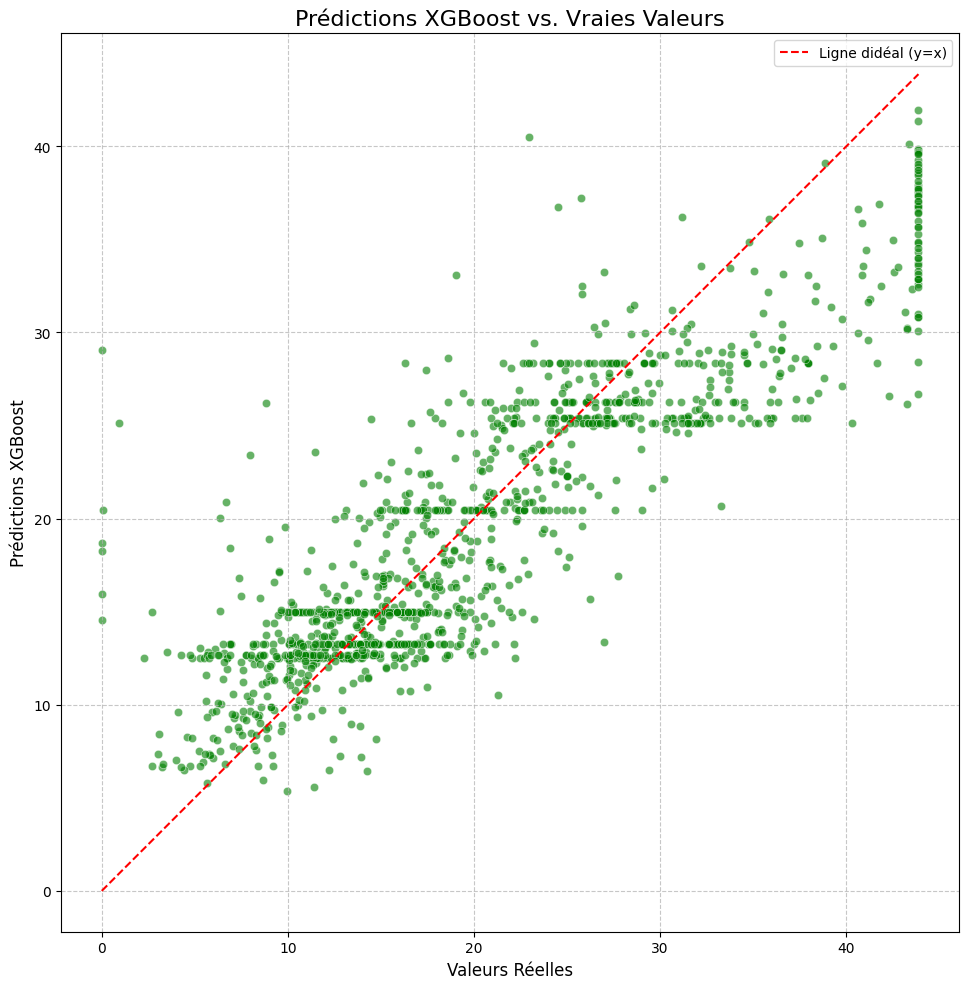

In [15]:
# Créer un DataFrame pour faciliter la visualisation des résultats XGBoost
results_xgb_df = pd.DataFrame({'Actual': y_test, 'Predicted_XGB': y_pred_xgb}, index=y_test.index)

# Visualisation des prédictions vs réalité pour l'entité 'NN5-001' avec XGBoost
results_xgb_entity = results_xgb_df[X_test['name'] == entity_to_plot]

plt.figure(figsize=(15, 7))
plt.plot(results_xgb_entity.index, results_xgb_entity['Actual'], label='Valeurs Réelles', color='blue', alpha=0.7)
plt.plot(results_xgb_entity.index, results_xgb_entity['Predicted_XGB'], label='Prédictions XGBoost', color='green', linestyle='--', alpha=0.7)
plt.title(f'Prédictions XGBoost vs. Valeurs Réelles pour {entity_to_plot}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur Capped', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot de prédictions XGBoost vs vraies valeurs
plt.figure(figsize=(10, 10))
sns.scatterplot(x='Actual', y='Predicted_XGB', data=results_xgb_df, alpha=0.6, color='green')
plt.plot([results_xgb_df['Actual'].min(), results_xgb_df['Actual'].max()],
         [results_xgb_df['Actual'].min(), results_xgb_df['Actual'].max()],
         '--r', label='Ligne d''idéal (y=x)')
plt.title('Prédictions XGBoost vs. Vraies Valeurs', fontsize=16)
plt.xlabel('Valeurs Réelles', fontsize=12)
plt.ylabel('Prédictions XGBoost', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

### 14. Optimisation de la Gestion des Liquidités Basée sur les Prévisions

Maintenant que nous avons des modèles capables de prédire la demande de liquidités avec une certaine précision, l'objectif final est d'utiliser ces prévisions pour optimiser la gestion des liquidités dans le secteur bancaire. Cela peut inclure des stratégies pour:

*   **Minimiser les coûts de financement** en anticipant les besoins de liquidités et en évitant les emprunts d'urgence à des taux élevés.
*   **Maximiser les rendements** des excédents de liquidités en les plaçant de manière judicieuse.
*   **Réduire les risques** de pénurie de liquidités en assurant une couverture adéquate.
*   **Améliorer la prise de décision** en fournissant aux gestionnaires de trésorerie des informations proactives.

Pour commencer, nous devons réfléchir aux indicateurs clés ou aux règles de décision qui pourraient être établis à partir de nos prévisions.

In [16]:
# Les prévisions de nos modèles (y_pred pour Random Forest et y_pred_xgb pour XGBoost)
# représentent la 'value_capped' future, c'est-à-dire la demande ou la liquidité ajustée.

# Pour l'optimisation, nous pourrions commencer par :
# 1. Analyser les prévisions par entité (chaque 'name') et par jour.
# 2. Définir des seuils ou des zones d'alerte basés sur ces prévisions.
# 3. Proposer des actions différentes en fonction des niveaux de prévision (par exemple, 'faible demande', 'demande normale', 'forte demande').

# Créons un DataFrame qui combine les prévisions XGBoost (qui était le meilleur) avec les caractéristiques de test.
# Cela nous permettra de lier les prévisions à chaque entité et date spécifiques.

optimization_df = X_test.copy()
optimization_df['actual_value'] = y_test
optimization_df['predicted_value'] = y_pred_xgb

print("Aperçu du DataFrame pour l'optimisation avec les prévisions:")
display(optimization_df.head())

# Nous pouvons ensuite agréger ces prévisions ou les analyser plus finement.
# Par exemple, calculer la demande totale prévue pour chaque jour ou pour chaque entité.

Aperçu du DataFrame pour l'optimisation avec les prévisions:


,name,weekday,day_of_month,actual_value,predicted_value
date,,,,,
1998-05-06,NN5-087,3,6,22.974750,20.911629
1998-05-06,NN5-022,3,6,21.910431,20.911629
1998-05-06,NN5-085,3,6,19.042609,15.300783
1998-05-06,NN5-023,3,6,15.189374,16.965775
1998-05-06,NN5-109,3,6,31.646825,30.454142


### 15. Définition des Seuils de Déficit et d'Excédent pour la Gestion des Liquidités

Pour une gestion proactive des liquidités, il est essentiel de définir des seuils clairs à partir de nos prévisions. Ces seuils nous aideront à identifier les situations où la demande réelle de liquidités pourrait dépasser (déficit) ou être bien inférieure (excédent) à ce qui a été prédit.

Nous allons d'abord calculer l'erreur de prédiction (résidu = valeur réelle - valeur prédite). Ensuite, nous utiliserons des quantiles de cette distribution d'erreurs pour définir des seuils opérationnels.

*   **Déficit Potentiel** : Si l'erreur est supérieure à un certain seuil positif (e.g., Q3 de l'erreur), cela signifie que la demande réelle a été significativement sous-estimée. Une action pourrait être de se préparer à une demande plus élevée que prévu.
*   **Excédent Potentiel** : Si l'erreur est inférieure à un certain seuil négatif (e.g., Q1 de l'erreur), cela signifie que la demande réelle a été significativement surestimée. Une action pourrait être de placer ces excédents de manière plus lucrative.
*   **Demande Normale** : Les erreurs se situant entre ces deux seuils. La gestion est alors considérée comme conforme aux prévisions.

Aperçu du DataFrame avec l'erreur de prédiction :


,name,weekday,day_of_month,actual_value,predicted_value,prediction_error
date,,,,,,
1998-05-06,NN5-087,3,6,22.974750,20.911629,2.063121
1998-05-06,NN5-022,3,6,21.910431,20.911629,0.998802
1998-05-06,NN5-085,3,6,19.042609,15.300783,3.741826
1998-05-06,NN5-023,3,6,15.189374,16.965775,-1.776401
1998-05-06,NN5-109,3,6,31.646825,30.454142,1.192684



Statistiques descriptives de l'erreur de prédiction :
count    1244.000000
mean        0.529271
std         4.919528
min       -29.033752
25%        -2.372640
50%         0.315870
75%         3.207289
max        17.201469
Name: prediction_error, dtype: float64


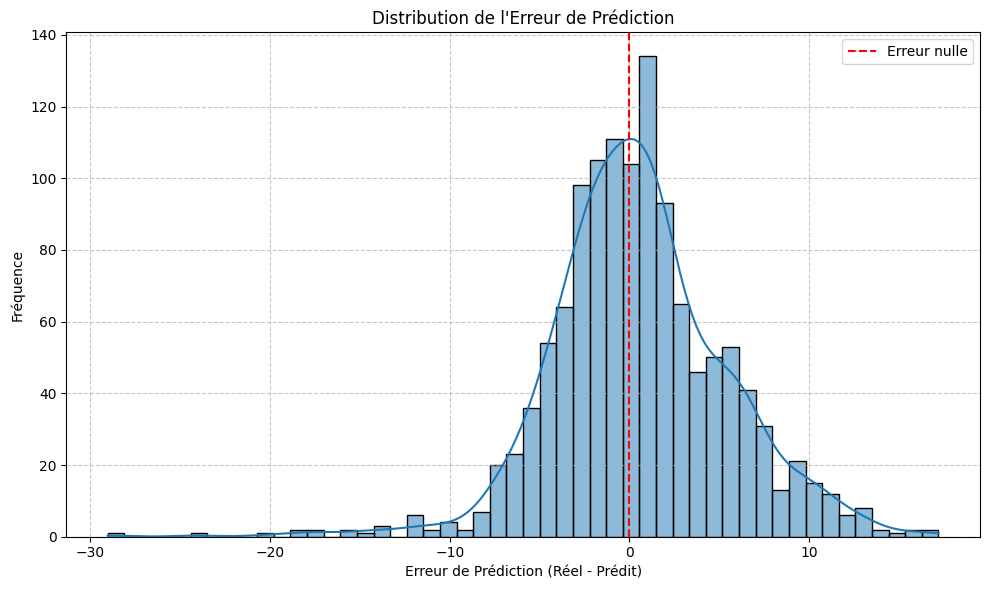


Seuil inférieur de l'erreur (Q1) : -2.373
Seuil supérieur de l'erreur (Q3) : 3.207

Répartition des statuts de liquidité :


,count
liquidity_status,
Demande Normale (Dans les attentes),622
Déficit Potentiel (Sous-estimation),311
Excédent Potentiel (Surestimation),311



Aperçu du DataFrame avec le statut de liquidité :


,name,weekday,day_of_month,actual_value,predicted_value,prediction_error,liquidity_status
date,,,,,,,
1998-05-06,NN5-087,3,6,22.974750,20.911629,2.063121,Demande Normale (Dans les attentes)
1998-05-06,NN5-022,3,6,21.910431,20.911629,0.998802,Demande Normale (Dans les attentes)
1998-05-06,NN5-085,3,6,19.042609,15.300783,3.741826,Déficit Potentiel (Sous-estimation)
1998-05-06,NN5-023,3,6,15.189374,16.965775,-1.776401,Demande Normale (Dans les attentes)
1998-05-06,NN5-109,3,6,31.646825,30.454142,1.192684,Demande Normale (Dans les attentes)


In [17]:
# Calcul de l'erreur de prédiction (résidu)
optimization_df['prediction_error'] = optimization_df['actual_value'] - optimization_df['predicted_value']

print("Aperçu du DataFrame avec l'erreur de prédiction :")
display(optimization_df.head())

# Analyse de la distribution des erreurs de prédiction
print("\nStatistiques descriptives de l'erreur de prédiction :")
print(optimization_df['prediction_error'].describe())

# Visualisation de la distribution des erreurs de prédiction
plt.figure(figsize=(10, 6))
sns.histplot(optimization_df['prediction_error'], kde=True, bins=50)
plt.title("Distribution de l'Erreur de Prédiction")
plt.xlabel("Erreur de Prédiction (Réel - Prédit)")
plt.ylabel("Fréquence")
plt.axvline(x=0, color='r', linestyle='--', label='Erreur nulle')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Définition des seuils basés sur les quantiles de l'erreur de prédiction
# Nous utiliserons le 25ème et le 75ème percentile comme seuils pour commencer
lower_error_threshold = optimization_df['prediction_error'].quantile(0.25)
upper_error_threshold = optimization_df['prediction_error'].quantile(0.75)

print(f"\nSeuil inférieur de l'erreur (Q1) : {lower_error_threshold:.3f}")
print(f"Seuil supérieur de l'erreur (Q3) : {upper_error_threshold:.3f}")

# Classer les prévisions en fonction de ces seuils
def categorize_liquidity_status(error):
    if error > upper_error_threshold:
        return 'Déficit Potentiel (Sous-estimation)'
    elif error < lower_error_threshold:
        return 'Excédent Potentiel (Surestimation)'
    else:
        return 'Demande Normale (Dans les attentes)'

optimization_df['liquidity_status'] = optimization_df['prediction_error'].apply(categorize_liquidity_status)

print("\nRépartition des statuts de liquidité :")
display(optimization_df['liquidity_status'].value_counts())

print("\nAperçu du DataFrame avec le statut de liquidité :")
display(optimization_df.head())